In [3]:
using Graphs
using GraphIO
using EzXML
using Wflow, GraphMakie, FilePaths

In [4]:
using DataStructures

In [5]:
using AttributeGraphs

In [ ]:
path = "../../data/wflow"

In [6]:
path = "/mnt/CEPH_PROJECTS/InterTwin/Wflow/models/adg1km_eobs/"

"/mnt/CEPH_PROJECTS/InterTwin/Wflow/models/adg1km_eobs/"

In [ ]:
config = Wflow.Config(joinpath(path, "wflow_sbm.toml") )

In [9]:
keys(config)

KeySet for a Dict{String, Any} with 13 entries. Keys:
  "output"
  "time_units"
  "starttime"
  "model"
  "csv"
  "state"
  "timestepsec"
  "calendar"
  "dir_output"
  "casename"
  "endtime"
  "input"
  "timestepsecs"

In [10]:
config.output.path = "bla.nc"

"bla.nc"

In [11]:
model = Wflow.initialize_sbm_model(config)

[ Info: Initialize model variables for model type `sbm`.
[ Info: Cyclic parameters are provided by `/mnt/CEPH_PROJECTS/InterTwin/Wflow/models/adg1km_eobs/staticmaps.nc`.
[ Info: Forcing parameters are provided by `/mnt/CEPH_PROJECTS/InterTwin/Wflow/models/adg1km_eobs/forcings.nc`.
[ Info: Set `vertical.precipitation` using NetCDF variable `precip` as forcing parameter.
[ Info: Set `vertical.temperature` using NetCDF variable `temp` as forcing parameter.
[ Info: Set `vertical.potential_evaporation` using NetCDF variable `pet` as forcing parameter.
[ Info: Set `vertical.leaf_area_index` using NetCDF variable `LAI` as cyclic parameter, with `12` timesteps.
┌ Info: General model settings
│   reservoirs = true
│   lakes = true
│   snow = true
│   masswasting = true
└   glacier = false
[ Info: Set `subcatchment` using NetCDF variable `wflow_subcatch`.
[ Info: Set `river_location` using NetCDF variable `wflow_river`.
[ Info: Set `lateral.river.width` using NetCDF variable `wflow_riverwidth`.


model of type Wflow.Model{@NamedTuple{land::@NamedTuple{graph::SimpleDiGraph{Int64}, upstream_nodes::Vector{Vector{Int64}}, subdomain_order::Vector{Vector{Int64}}, topo_subdomain::Vector{Vector{Int64}}, indices_subdomain::Vector{Vector{Int64}}, order::Vector{Int64}, indices::Vector{CartesianIndex{2}}, reverse_indices::Matrix{Int64}, xl::Vector{Float64}, yl::Vector{Float64}, slope::Vector{Float64}}, river::@NamedTuple{graph::SimpleDiGraph{Int64}, indices::Vector{CartesianIndex{2}}, reverse_indices::Matrix{Int64}, upstream_nodes::Vector{Vector{Int64}}, subdomain_order::Vector{Vector{Int64}}, topo_subdomain::Vector{Vector{Int64}}, indices_subdomain::Vector{Vector{Int64}}, order::Vector{Int64}}, reservoir::@NamedTuple{indices_outlet::Vector{CartesianIndex{2}}, indices_coverage::Vector{Vector{CartesianIndex{2}}}, reverse_indices::Matrix{Int64}}, lake::@NamedTuple{indices_outlet::Vector{CartesianIndex{2}}, indices_coverage::Vector{Vector{CartesianIndex{2}}}, reverse_indices::Matrix{Int64}}, 

In [12]:
wrgraph = model.network.river.graph 

wrgraph

wlgraph = model.network.land.graph 

wlgraph

{15459, 15458} directed simple Int64 graph

In [13]:
savegraph("land_graph_big.ml",  wlgraph, "wflow", GraphIO.GraphML.GraphMLFormat())

1

In [14]:
savegraph("river_graph_big.ml",  wrgraph, "wflow", GraphIO.GraphML.GraphMLFormat())

1

In [45]:
model.vertical.soilthickness

1236.8363037109375

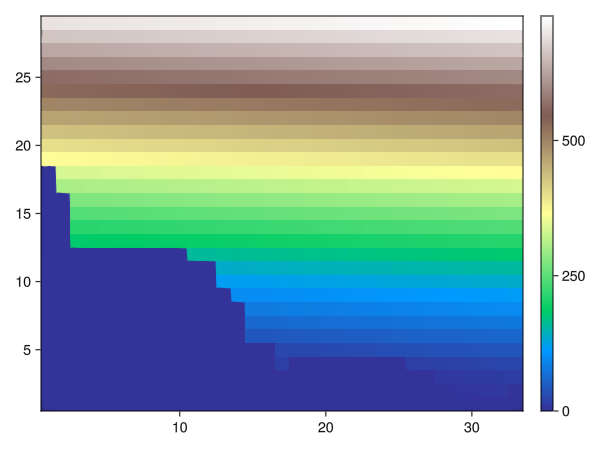

In [65]:
fig,ax, hm =heatmap(model.network.land.reverse_indices,colormap="terrain")
Colorbar(fig[:, end+1], hm)
fig

In [55]:
?heatmap

search: heatmap heatmap! Heatmap



```
heatmap(x, y, matrix)
heatmap(x, y, func)
heatmap(matrix)
heatmap(xvector, yvector, zvector)
```

Plots a heatmap as a collection of rectangles. `x` and `y` can either be of length `i` and `j` where `(i, j)` is `size(matrix)`, in this case the rectangles will be placed around these grid points like voronoi cells. Note that for irregularly spaced `x` and `y`, the points specified by them are not centered within the resulting rectangles.

`x` and `y` can also be of length `i+1` and `j+1`, in this case they are interpreted as the edges of the rectangles.

Colors of the rectangles are derived from `matrix[i, j]`. The third argument may also be a `Function` (i, j) -> v which is then evaluated over the grid spanned by `x` and `y`.

Another allowed form is using three vectors `xvector`, `yvector` and `zvector`. In this case it is assumed that no pair of elements `x` and `y` exists twice. Pairs that are missing from the resulting grid will be treated as if `zvector` had a `NaN`     element at that position.

If `x` and `y` are omitted with a matrix argument, they default to `x, y = axes(matrix)`.

Note that `heatmap` is slower to render than `image` so `image` should be preferred for large, regularly spaced grids.

## Attributes

### Specific to `Heatmap`

  * `interpolate::Bool = false` sets whether colors should be interpolated.

### Color attributes

  * `colormap::Union{Symbol, Vector{<:Colorant}} = :viridis` sets the colormap that is sampled for numeric `color`s. `PlotUtils.cgrad(...)`, `Makie.Reverse(any_colormap)` can be used as well, or any symbol from ColorBrewer or PlotUtils. To see all available color gradients, you can call `Makie.available_gradients()`.
  * `colorscale::Function = identity` color transform function. Can be any function, but only works well together with `Colorbar` for `identity`, `log`, `log2`, `log10`, `sqrt`, `logit`, `Makie.pseudolog10` and `Makie.Symlog10`.
  * `colorrange::Tuple{<:Real, <:Real}` sets the values representing the start and end points of `colormap`.
  * `nan_color::Union{Symbol, <:Colorant} = RGBAf(0,0,0,0)` sets a replacement color for `color = NaN`.
  * `lowclip::Union{Nothing, Symbol, <:Colorant} = nothing` sets a color for any value below the colorrange.
  * `highclip::Union{Nothing, Symbol, <:Colorant} = nothing` sets a color for any value above the colorrange.
  * `alpha = 1.0` sets the alpha value of the colormap or color attribute. Multiple alphas like in `plot(alpha=0.2, color=(:red, 0.5)`, will get multiplied.

### Generic attributes

  * `visible::Bool = true` sets whether the plot will be rendered or not.
  * `overdraw::Bool = false` sets whether the plot will draw over other plots. This specifically means ignoring depth checks in GL backends.
  * `transparency::Bool = false` adjusts how the plot deals with transparency. In GLMakie `transparency = true` results in using Order Independent Transparency.
  * `fxaa::Bool = true` adjusts whether the plot is rendered with fxaa (anti-aliasing).
  * `inspectable::Bool = true` sets whether this plot should be seen by `DataInspector`.
  * `depth_shift::Float32 = 0f0` adjusts the depth value of a plot after all other transformations, i.e. in clip space, where `0 <= depth <= 1`. This only applies to GLMakie and WGLMakie and can be used to adjust render order (like a tunable overdraw).
  * `model::Makie.Mat4f` sets a model matrix for the plot. This replaces adjustments made with `translate!`, `rotate!` and `scale!`.
  * `space::Symbol = :data` sets the transformation space for box encompassing the volume plot. See `Makie.spaces()` for possible inputs.
